<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L2-FraudDetection/Task3_FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Inspect structure
print("Dataset Shape:", df.shape)

Dataset Shape: (210013, 31)


# Analyze Class Imbalance

We will calculate the exact percentage of fraudulent transactions to understand the severity of the class imbalance.

Normal Transactions: 209618
Fraudulent Transactions: 394
Percentage of Fraud: 0.188%


/tmp/ipykernel_1413/1108330165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set1')


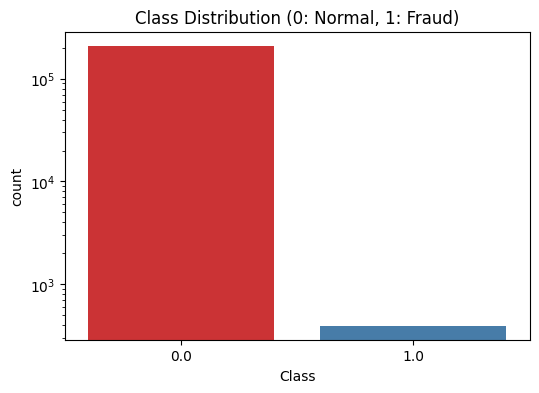

In [6]:
fraud_count = df['Class'].value_counts()
fraud_percentage = (fraud_count[1] / len(df)) * 100

print(f"Normal Transactions: {fraud_count[0]}")
print(f"Fraudulent Transactions: {fraud_count[1]}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%")

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # Use log scale because the imbalance is so extreme
plt.show()

# Exploratory Data Analysis (EDA)

Let's analyze the distribution of transaction amounts and the time of day for both normal and fraudulent transactions.

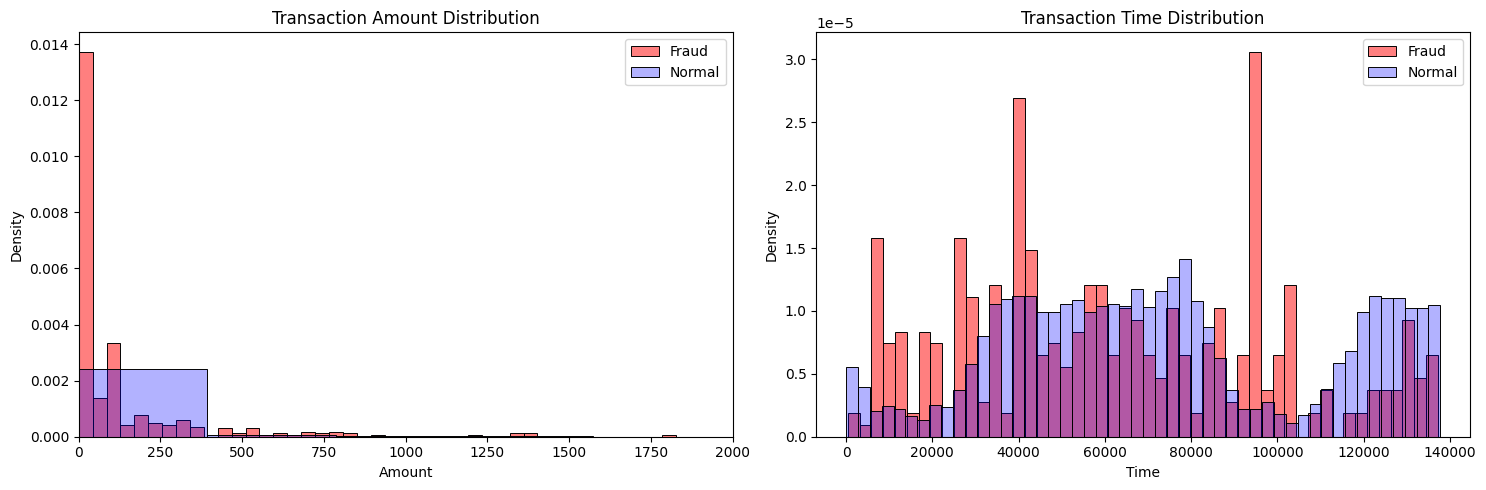

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Transaction Amount Distribution
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=axes[0], color='red', stat='density', alpha=0.5, label='Fraud')
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=axes[0], color='blue', stat='density', alpha=0.3, label='Normal')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlim(0, 2000)
axes[0].legend()

# Time Distribution
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, ax=axes[1], color='red', stat='density', alpha=0.5, label='Fraud')
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, ax=axes[1], color='blue', stat='density', alpha=0.3, label='Normal')
axes[1].set_title('Transaction Time Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Why Accuracy is a Misleading Metric

In a dataset where 99.8% of transactions are normal, a "dumb" model that simply predicts every transaction as normal will achieve 99.8% accuracy. However, this model is entirely useless because it fails to catch a single instance of fraud.

For fraud detection, we must evaluate our models using Recall (out of all actual frauds, how many did we catch?) and Precision (out of all the transactions we flagged as fraud, how many were actually fraud?), rather than standard accuracy.

In [8]:
# 1. Drop any rows that contain missing values to prevent errors
df = df.dropna()

# 2. Separate features (X) and target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 3. Train/Test Split (stratified to ensure frauds appear in both sets)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data successfully cleaned and split!")

Data successfully cleaned and split!


# Handling Imbalance with SMOTE

We will use SMOTE (Synthetic Minority Over-sampling Technique) on our training data only to generate synthetic fraudulent transactions, balancing the classes so our models can properly learn the fraud patterns.

In [9]:
print("Before SMOTE, training label counts:\n", y_train.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE, training label counts:\n", pd.Series(y_train_smote).value_counts())

Before SMOTE, training label counts:
 Class
0.0    167694
1.0       315
Name: count, dtype: int64

After SMOTE, training label counts:
 Class
0.0    167694
1.0    167694
Name: count, dtype: int64


# Model Training

We will train two models on the SMOTE-balanced data: a baseline Logistic Regression model and a Random Forest Classifier.

In [14]:
from sklearn.preprocessing import StandardScaler

print("Scaling data...")
# 1. Scale the data so Logistic Regression can converge instantly
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Training Logistic Regression...")
# 2. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote_scaled, y_train_smote)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Training Random Forest (This may take 1-3 minutes)...")
# 3. Train Random Forest (n_jobs=-1 speeds it up by using all CPU cores)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote_scaled, y_train_smote)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete! You can move to the next step.")

Scaling data...
Training Logistic Regression...
Training Random Forest (This may take 1-3 minutes)...
Model training complete! You can move to the next step.


# Model Evaluation

We will evaluate both models using Precision, Recall, F1-Score, and the AUC-ROC curve.

In [15]:
def evaluate_model(name, y_true, y_pred, y_probs):
    print(f"--- {name} ---")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_true, y_probs):.4f}\n")

evaluate_model("Logistic Regression", y_test, lr_preds, lr_probs)
evaluate_model("Random Forest", y_test, rf_preds, rf_probs)

--- Logistic Regression ---
Precision: 0.1637
Recall:    0.9241
F1-Score:  0.2781
AUC-ROC:   0.9851

--- Random Forest ---
Precision: 0.7419
Recall:    0.8734
F1-Score:  0.8023
AUC-ROC:   0.9908



# AUC-ROC Curve Visualization

We will plot the Receiver Operating Characteristic curve to visually compare the performance of both models.

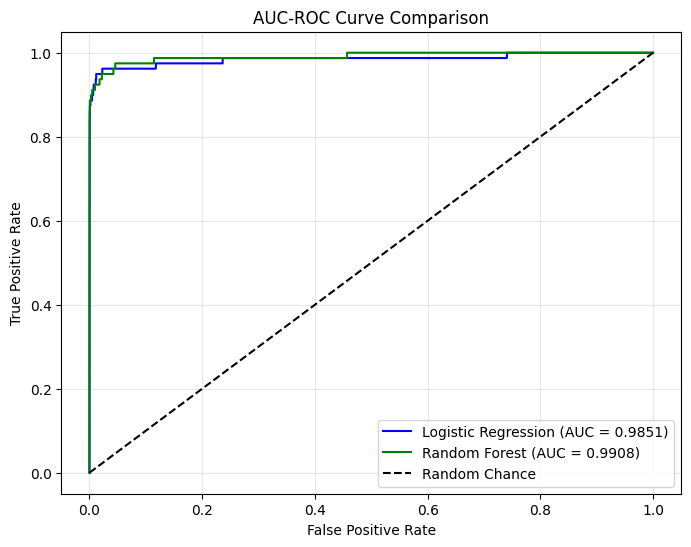

In [18]:
# The scaled test data is named X_test_scaled from our previous step
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.4f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('AUC-ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Feature Importance

We will extract the feature importances from the Random Forest model to see which of the PCA-transformed variables were most critical in identifying fraud.

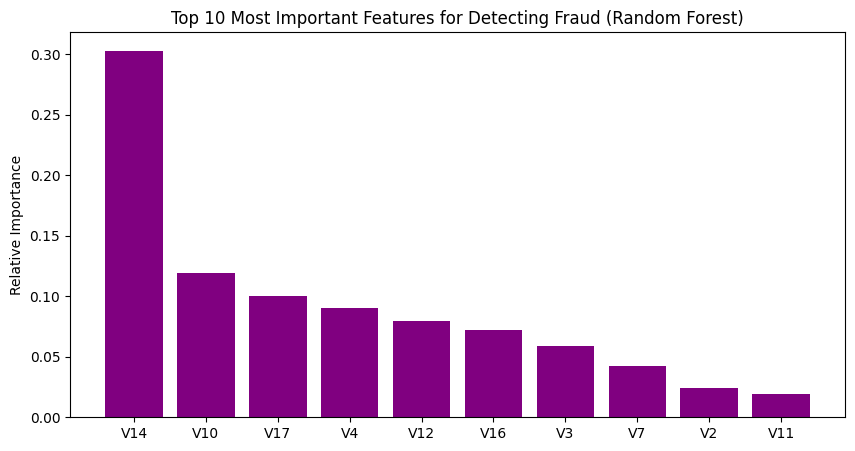

In [19]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices][:10], align="center", color='purple')
plt.xticks(range(10), X.columns[indices][:10])
plt.title("Top 10 Most Important Features for Detecting Fraud (Random Forest)")
plt.ylabel("Relative Importance")
plt.show()

# Discussion & Scalability

Recall vs. Precision Trade-off: In fraud detection, Recall is generally prioritized over Precision. It is better to falsely flag a normal transaction as fraud (low precision) and mildly inconvenience a customer with a verification text, rather than miss a truly fraudulent transaction (low recall) which results in direct financial loss.

Scalability (1 Million Transactions/Hour): To handle extreme scale, these models cannot process data in massive batch jobs. The architecture would require:

1. Streaming Data Pipelines: Using tools like Apache Kafka to ingest transactions in real-time.

2. Model Serving: Deploying the trained model via a highly optimized API endpoint (e.g., using FastAPI and ONNX runtime) that can deliver microsecond inference times.

3. Feature Store: Maintaining an ultra-fast caching layer (like Redis) to instantly access a customer's rolling behavioral features (e.g., "amount spent in the last hour") without recalculating them on the fly.